# Programming exercise 8: Entanglement and the transverse field Ising model

Due on Monday, 15.06.2026, 20h

In [1]:
# load standard libraries

import numpy as np   # standard numerics library
import scipy as sc
import numpy.linalg as LA
import scipy.linalg as sciLA
import scipy.constants as scicon
import matplotlib.pyplot as plt   # for making plots

import time as time

from scipy.sparse import kron
import scipy.sparse as sparse
import scipy.sparse.linalg as sLA
from scipy.special import binom

from ipywidgets import interactive, interact
from ipywidgets import FloatSlider

from qutip import (tensor, basis) 

import Comp_Quant_Dynam as cqd

### Exercise 1: Building general spin 1/2 Hamiltonians

In the past exercises we have worked with the *collective* Ising model, where we could use the permutation symmetry to reduce the Hilbert space dimension from $2^N$ to $N+1$. This time we want to consider a model with nearest-neighbour spin interactions, the one-dimensional transverse-field Ising model (TFIM), where the permutation symmetry no longer holds. This model is analytically solvable (see e.g. https://www.sciencedirect.com/science/article/pii/0003491670902708). For the sake of learning how to build general spin models, we will solve it here by numerical means and compare the result to the exact solution as a check. The tools you develop here you can then apply to build any spin Hamiltonian straightforwardly. The Hamiltonian of the TFIM reads
$$
H=\sum_{i=0}^{N-1} -J\sigma_z^{(i)}\sigma_z^{(i+1)} - B \sigma_x^{(i)}
$$
where we want to use periodic boundary conditions, i.e. the $N$th spin is identified with the $0$th spin.

To solve it we first set up a framework for general spin 1/2 models.
We will work in the canonical product basis of states $|i_0,...,i_{N-1}\rangle$, where $i_k \in {0,1}$. This basis of course has the problem of exponential scaling of the number of basis states with particle number N. But we still want to use it to keep our approach as general as possible, which then just allows us to use up to 12 or so spins with reasonable computation time.

The recipe for constructing general spin models is the following:

1) Define the single-spin operators $s_x$, $s_y$, $s_z$, and the 2x2 identity, $\mathbb{1}$ as sparse matrices (csr_matrix should work best).

2) Build a list of all single-spin operators acting on spin $i=0...N-1$ in the $N$-spin Hilbert space.
$$
s_\alpha^{(i)} = \mathbb{1}^{\otimes i}\otimes s_\alpha \otimes \mathbb{1}^{\otimes (N-i-1)}
$$
where $\alpha \in \{x,y,z\}$. Use the Kronecker product for sparse matrices to do this. (Make sure you understand how the indexing/ordering of the matrix elements is done by `kron()`!)

3) Construct the Hamiltonian (or any other Hermitian operator) by adding up its individual terms, using the dot product for interaction terms. Remember that the Hamiltonian was defined with Pauli operators, not spin operators, which differ by a factor of two. (Alternatively, you could build all the Pauli operators in the $N$-particle Hilbert space instead of the spin operators.)

Test your implementation by calculating the ground state energy of the transverse field Ising model and comparing it to the analytical result (for even $N$)
$$
E_0^{analyt} = -\sum_{k=-(N-1)/2}^{(N-1)/2}\sqrt{1+B^2 + 2B\cos(2\pi k/N)}
$$
where the $J=1$ was chosen without loss of generality.

Calculate a few low lying eigenpairs for $N=10$ and a grid of $B$-values between 0 and 2 and plot the numerical and analytical result for the ground state energy. Keep in mind that compared to the reference given above, there might be factors of two differences since they define the Hamiltonian with spin operators instead of Pauli operators.

Also think about what the ground state should be at large $B$ and at $B=0$.

In [2]:
### 1.1

s_x = 1/2* sparse.csr_matrix([[0, 1],               # hbar = 1
                      [1, 0]], dtype=complex)

s_y = 1/2* sparse.csr_matrix([[0, -1j],
                      [1j, 0]], dtype=complex)

s_z = 1/2* sparse.csr_matrix([[1, 0],
                      [0, -1]], dtype=complex)

I = sparse.identity(2, format='csr', dtype=complex)

### 1.2
N = 10
def single_spin_op(N):
    sx_list = []
    sy_list = []
    sz_list = []

    for i in range(N):

        sx_i = sparse.csr_matrix([[1]], dtype=complex)
        sy_i = sparse.csr_matrix([[1]], dtype=complex)
        sz_i = sparse.csr_matrix([[1]], dtype=complex)

        for j in range(N):

            sx_i = kron(sx_i, s_x if j == i else I, format='csr')
            sy_i = kron(sy_i, s_y if j == i else I, format='csr')
            sz_i = kron(sz_i, s_z if j == i else I, format='csr')

        sx_list.append(sx_i)    #list with all possible i values
        sy_list.append(sy_i)
        sz_list.append(sz_i) 

    return sx_list, sy_list, sz_list

sx_list, sy_list, sz_list = single_spin_op(N)

### 1.3
def sigma_operators(sx_list, sy_list, sz_list):
    sigma_x_list = [2 * op for op in sx_list]   # single spin operators to single pauli matrices
    sigma_y_list = [2 * op for op in sy_list]
    sigma_z_list = [2 * op for op in sz_list]
    return sigma_x_list, sigma_y_list, sigma_z_list

sigma_x_list, sigma_y_list, sigma_z_list = sigma_operators(sx_list, sy_list, sz_list)

#Hamiltonian
def H_spin(B,J,sigma_x_list,sigma_z_list,N):
    H_x = sum(sigma_x_list[i] for i in range(N))
    H_x = -B * H_x

    H_z = sparse.csr_matrix((2**N, 2**N), dtype=complex)
    for i in range(N-1):
        H_z += sigma_z_list[i].dot(sigma_z_list[i+1])
    #boundary condition
    H_z += sigma_z_list[N-1].dot(sigma_z_list[0])

    H_spin = -J*H_z + H_x
    return H_spin



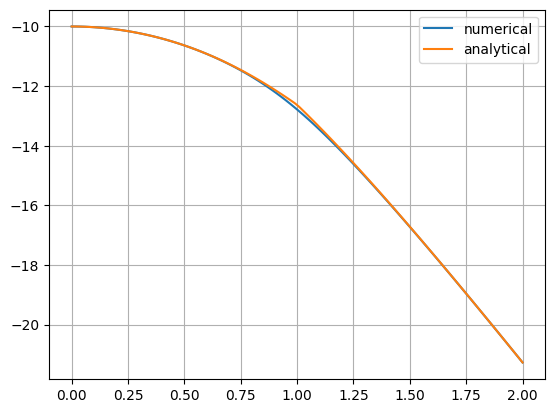

In [3]:
### test numerical with analytical
J =  1
B = np.linspace(0,2,100)
E_vals = []
for Bval in B:
    H = H_spin(Bval,J,sigma_x_list,sigma_z_list,N)
    eval = sLA.eigsh(H,1,which="SA")[0]
    E_vals.append(eval[0])
#analytical
def E0_analyt(B, N):
    k = np.arange(-(N-1)//2, (N-1)//2 + 1)
    return - np.sum(np.sqrt(1 + B**2 + 2*B*np.cos(2*np.pi*k/N)))
E_vals_ana = []
for Bval in B:
    E_vals_ana.append(E0_analyt(Bval,N))


plt.plot(B,E_vals,label="numerical")
plt.plot(B,E_vals_ana,label="analytical")
plt.legend()
plt.grid()
plt.show()


### Exercise 2: Taking partial traces

The TFIM has a quantum phase transition at $B/J=1$ from a ferromagnetic to a paramagnetic phase. You can use your code from exercise 1 to see that the gap is minimal around this value. Note that the model also has the $Z_2$ symmetry (invariance under flipping of all spins) which we saw in the collective Ising model, so you would look at the gap of ground and second excited state.
At the phase transition point (or quantum critical point), long-range correlations emerge in the ground state. An interesting feature is also that at the quantum critical point the half-chain entanglement entropy diverges logarithmically as $N$ goes to infinity (see for example https://arxiv.org/abs/0803.3610 Fig. 3). For finite $N$ we should already see that the entanglement entropy becomes maximal approximately at the quantum critical point.

To calculate the half-chain entanglement entropy in the ground state of the transverse Ising chain, you should proceed as follows:

1) Calculate the partial trace over $N/2$ spins. The matrix element of the reduced density of a state $|\psi\rangle = \sum_i c_i |i\rangle$ (where $|i\rangle$ are the $N$-spin basis states) can be expressed as
$$
(\rho_{red,N/2})_{ij} = \sum_{k=0}^{2^{N/2}-1} c_{i+k*2^{N/2}}c^*_{j+k*2^{N/2}}
$$
(This might look different depending on how the states are ordered in your basis.)

2) Calculate the eigenvalues $p_i$ of $\rho_{red,N/2}$, sort them from largest to smallest. This is the entanglement spectrum. The rank of $\rho_{red,N/2}$ is called entanglement dimension (or Schmidt rank). For a separable state the entanglement dimension is 1, i.e. only one eigenvalue is non-zero. (Note that in the lecture we defined the eigenvalues as $\lambda_i$.)

3) Calculate the von-Neumann entanglement entropy $S_E = -\sum_i p_i \log(p_i)$. Consider that some of the eigenvalues can be zero. Due to the finite numerical precision they can even turn negative. These you want to exclude from the sum. (Since $\lim_{p\rightarrow 0} p\log(p) =0$ we are not modifying the outcome significantly by neglecting small p's.)

Test your code for some cases where you know the answer, for example a separable state or a Bell pair state of 2 qubits. The qutip library also has the capability of calculating partial traces. If you are interested you can compare to this for testing.

Then calculate the entanglement spectrum and entropy for the same parameter scan as in exercise 1. Document your observations.

Optional: Try to see to how large $N$ you can push the numerics. Observe the $N$-scaling of ground state entanglement at the critical point.

Optional: Calculate the Schmidt coefficients using the singular value decomposition. This should actually be technically easier than calculating partial traces (see lecture notes).

In [4]:
# 2.1
B = 1
J = 1
evals, evecs = sLA.eigsh(H, k=1, which="SA")
psi = evecs[:,0]            #ground state

def reduced_density_matrix(psi, N):

    dimA = 2**(N//2)

    psi_mat = psi.reshape(dimA, dimA)

    return psi_mat @ psi_mat.conj().T
# 2.2
#Eigenvalues sorted from largest to lowest
rho_red = reduced_density_matrix(psi,N)
eigvals, _ = sLA.eigsh(rho_red,which="LM")
print("Eigenspectrum of reduced state: ", eigvals)   
print("The Schmidt rank of the state is ",len(eigvals)) 

# 2.3
def S(N,eigvals):
    eigvals = eigvals [eigvals >= 1e-12]   #only positive values
    entropy = - np.sum(eigvals*np.log2(eigvals))
    print("Entropie of TIM for N =", N,"particles is ",entropy)
    return entropy



Eigenspectrum of reduced state:  [9.64859720e-01 1.91643722e-02 1.56516272e-02 3.10877947e-04
 1.15582394e-05 1.37355126e-06]
The Schmidt rank of the state is  6


In [7]:
# testing of entropy for different states

# seperable state
N = 2
psi = np.array([1,0,0,0],dtype=complex)
rho_red_sep = reduced_density_matrix(psi,N)
eigvals, _ = sLA.eigsh(rho_red_sep, which="LM")
S(N,eigvals)

# Bell state
N = 2
psi = 1/np.sqrt(2)*np.array([1,0,0,1],dtype=complex)
rho_red_sep = reduced_density_matrix(psi,N)
eigvals, _ = sLA.eigsh(rho_red_sep, which="LM")
S(N,eigvals)

Entropie of TIM for N = 2 particles is  -0.0
Entropie of TIM for N = 2 particles is  1.0


np.float64(1.0)

Entropie of TIM for N = 2 particles is  0.6008760366928563
Entropie of TIM for N = 4 particles is  0.7528978402737947
Entropie of TIM for N = 6 particles is  0.8479265692034431
Entropie of TIM for N = 8 particles is  0.916249367104934
Entropie of TIM for N = 10 particles is  0.9695123579233673
Entropie of TIM for N = 12 particles is  1.0131391010818616
Entropie of TIM for N = 14 particles is  1.0500766274997202
Entropie of TIM for N = 16 particles is  1.0821012019344876
Entropie of TIM for N = 18 particles is  1.1103651995263055
Entropie of TIM for N = 20 particles is  1.135658407062235


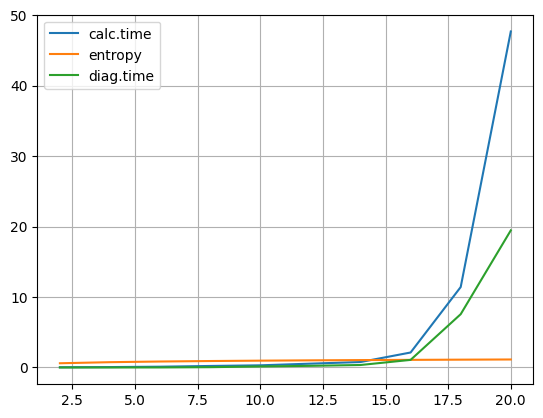

In [6]:
#time and entropy for different N

#starting parameters
B = 1 
J = 1
entropy_vals = []
time_vals = []
time_diag = []
n=[]
for k in range(2,22,2):
    # calculating single spin operators and hamiltonian
    t0 = time.time()    #starting time
    sx_list, sy_list, sz_list = single_spin_op(k)
    sigma_x_list, sigma_y_list, sigma_z_list = sigma_operators(sx_list, sy_list, sz_list)
    H = H_spin(B,J,sigma_x_list,sigma_z_list,k)

    #ground state and reduced matrix
    t0_diag = time.time()
    eval, evecs = sLA.eigsh(H,1,which="SA")
    t1_diag = time.time()
    t_diag = t1_diag - t0_diag
    time_diag.append(t_diag)
    psi = evecs[:,0]
    rho_red = reduced_density_matrix(psi,k)
    eigval_red = np.linalg.eigvalsh(rho_red)

    #entropy
    entropy = S(k,eigval_red)
    t1 = time.time()
    t_tot = t1-t0
    time_vals.append(t_tot)
    entropy_vals.append(entropy)
    n.append(k)
plt.plot(n,time_vals,label="calc.time")
plt.plot(n,entropy_vals,label="entropy")
plt.plot(n,time_diag,label="diag.time")
plt.legend()
plt.grid()
plt.show()


### Optional Exercise 3: Time-dependence of entanglement entropy

Calculate the time-evolution for all spins being in the state $|+\rangle = (|0\rangle+|1\rangle)/\sqrt{2}$ initially.

If you evolve this state with the quantum critical Ising Hamiltonian, the entanglement entropy should increase very rapidly in time and saturate due to the finite system size. The saturation value is extensive in system size (volume law). This makes simulating the time evolution for quenches near the critical point challenging for techniques based on matrix product states (next lecture).

### Optional Exercise 4: Spin squeezing and entanglement

Let us look at the *collective* Ising spin-model with a transverse field one last time. The Hamiltonian is still
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. This time we want to examine how spin squeezed states form under the dynamics of this model. All we have to do is to initialize the system with all spins pointing along the x-direction, i.e. in the coherent spin state $|CSS(\pi/2,0)\rangle$. For any small value of $\Omega$ (we can actually choose $\Omega=0$) we will observe spin squeezing.

Plot the Husimi distribution of the state using the "front view" from programming exercise 7 and observe how it evolves with time. Evaluate $S_x$ and the variance in any direction perpendicular to $S_x$ by rotating the state about the x-axis and calculating the variance of $S_z$ to determine the direction of maximal squeezing.

Calculate the optimal squeezing parameter $\min_{\mathbf{n}_\perp} = N (\Delta (\mathbf{n}_\perp\cdot \mathbf{S}))^2/\langle S_x\rangle^2$ as a function of time. Why does it increase again after some time?

Spin squeezing is associated with the buildup of entanglement. Calculate the entanglement entropy for the above time evolution. You can use the techniques from exercises 1 and 2 for this and solve the collective Ising model in the product basis, which of course allows you only to go to small numbers of spins, but the effects will still be visible. Note that one can also calculate the reduced density using symmetrized Dicke states (see https://arxiv.org/abs/cond-mat/0409611). You can implement this as a cross check and for going to larger N.